In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('temp.csv', index_col = 'Date')
data.index = pd.DatetimeIndex(data.index).to_period('D')

# 截断最后三十天的记录数据、用于检验预测效果
train_data, test_data = data.truncate(after = '1990-12-01'), data.truncate(before = '1990-12-02') 
print(train_data.tail())
print(test_data.tail())

            Temp
Date            
1990-11-27   8.8
1990-11-28  14.7
1990-11-29  14.7
1990-11-30  12.7
1990-12-01  13.3
            Temp
Date            
1990-12-27  14.0
1990-12-28  13.6
1990-12-29  13.5
1990-12-30  15.7
1990-12-31  13.0


(-4.4472335361439805, 0.00024462587422054686, 20, 3599, {'1%': -3.4321682745778963, '5%': -2.86234341192807, '10%': -2.56719766893431}, 16510.41587616864)
         lb_stat  lb_pvalue
1    2167.272518        0.0
2    3601.601356        0.0
3    4840.883671        0.0
4    6052.150879        0.0
5    7264.612102        0.0
6    8470.062655        0.0
7    9671.815950        0.0
8   10846.457363        0.0
9   11994.151007        0.0
10  13082.816052        0.0


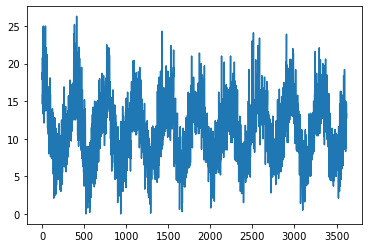

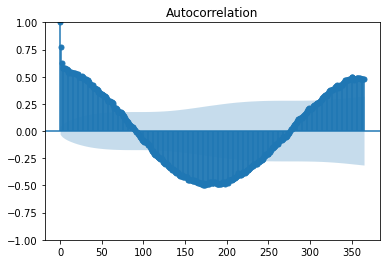

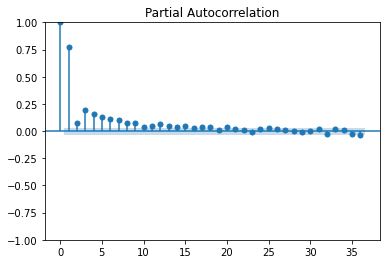

In [2]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

##时序图
plt.plot(train_data.values)

##自相关系数，偏自相关系数
#acf_data = acf(train_data)
#acf_data = pd.DataFrame(acf_data)
#acf_data.plot()
plot_acf(train_data, lags = 365).show()
plot_pacf(train_data, method = 'ywm').show()

##单位根检验、平稳性检验
print(adfuller(train_data))

##白噪声检验
print(acorr_ljungbox(train_data))

In [3]:
from statsmodels.tsa.ar_model import AutoReg
from functools import reduce

test_bic = lambda data, lags: AutoReg(data, lags = lags).fit().bic

Hyperparameters = reduce(lambda a, b: a if test_bic(train_data, a) < test_bic(train_data, b) else b, (x for x in range(35)))
print(f'最佳超参数为:\t{Hyperparameters}')

最佳超参数为:	22


In [4]:
AR2_model = AutoReg(train_data, lags = Hyperparameters).fit()

print(AR2_model.summary())

# 模型预测
predict = AR2_model.predict('1990-12-02', '1990-12-31')

                            AutoReg Model Results                             
Dep. Variable:                   Temp   No. Observations:                 3620
Model:                    AutoReg(22)   Log Likelihood               -8250.167
Method:               Conditional MLE   S.D. of innovations              2.397
Date:                Wed, 30 Nov 2022   AIC                          16548.335
Time:                        07:21:02   BIC                          16696.850
Sample:                    01-23-1981   HQIC                         16601.264
                         - 12-01-1990                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6002      0.147      4.095      0.000       0.313       0.887
Temp.L1        0.5880      0.017     35.304      0.000       0.555       0.621
Temp.L2       -0.0929      0.019     -4.809      0.0

In [5]:
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

# 计算误差
predict = pd.DataFrame(predict, columns = ['pred'])
d = pd.concat([test_data, predict], axis = 1)
d['error'] = d['Temp'] - d['pred']
print(d)

            Temp       pred     error
1990-12-02  13.2  12.351970  0.848030
1990-12-03  16.2  12.233568  3.966432
1990-12-04  17.3  12.193307  5.106693
1990-12-05  20.5  12.144493  8.355507
1990-12-06  20.2  12.049521  8.150479
1990-12-07  19.4  12.042436  7.357564
1990-12-08  15.5  11.889090  3.610910
1990-12-09  14.1  12.016066  2.083934
1990-12-10  11.0  12.057872 -1.057872
1990-12-11  11.1  12.141441 -1.041441
1990-12-12  14.0  12.110839  1.889161
1990-12-13  11.4  11.977571 -0.577571
1990-12-14  12.5  12.193359  0.306641
1990-12-15  13.4  12.154499  1.245501
1990-12-16  13.6  12.084353  1.515647
1990-12-17  13.9  12.177293  1.722707
1990-12-18  17.2  12.199410  5.000590
1990-12-19  14.7  12.164347  2.535653
1990-12-20  15.4  12.121491  3.278509
1990-12-21  13.1  12.079154  1.020846
1990-12-22  13.2  12.047162  1.152838
1990-12-23  13.9  12.027867  1.872133
1990-12-24  10.0  12.012901 -2.012901
1990-12-25  12.9  11.994023  0.905977
1990-12-26  14.6  11.976838  2.623162
1990-12-27  